# Notebook 3 — Model Training, Stacking Ensemble & Selection

**Barclays Credit Intelligence Platform – Hackathon Submission**

| Step | Detail |
|------|--------|
| Inputs | `combined_training_data.csv`, `feature_list.json` from Notebook 2 |
| Baselines | Logistic Regression · Random Forest · KNN |
| Base learners | XGBoost (Optuna-tuned) · LightGBM · CatBoost |
| Meta-learner | Logistic Regression on OOF probabilities |
| Tuner | Optuna (60 trials on XGBoost) |
| Imbalance | class_weight + SMOTE comparison |
| Calibration | Isotonic regression |
| Metrics | **AUC-ROC · Accuracy · Precision · Recall · F1** + KS · Gini · Brier |
| Output | Trained stacking pipeline, threshold, artifacts |

In [2]:
!pip install catboost optuna xgboost lightgbm imbalanced-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 36.8 MB/s eta 0:00:00


In [3]:
# Install missing packages (run once)
!pip install catboost optuna xgboost lightgbm imbalanced-learn -q

import warnings, json, os, pickle, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, fbeta_score,
    brier_score_loss, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    log_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
SEED = 42
np.random.seed(SEED)

# ── Mount Google Drive ──
from google.colab import drive
drive.mount('/content/drive')

# ── Point to the Drive folder that contains the artifacts ──
ARTIFACT_ROOT = Path('/content/drive/MyDrive/home_credit_artifacts')
ARTIFACT_DIR = ARTIFACT_ROOT / 'artifacts'
OUTPUT_DIR   = ARTIFACT_ROOT / 'outputs'
MODEL_DIR    = OUTPUT_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"ARTIFACT_DIR: {ARTIFACT_DIR}")
print(f"MODEL_DIR:    {MODEL_DIR}")

Mounted at /content/drive
ARTIFACT_DIR: /content/drive/MyDrive/home_credit_artifacts/artifacts
MODEL_DIR:    /content/drive/MyDrive/home_credit_artifacts/outputs/models


In [4]:
# List contents of the artifacts folder
import os
print("Artifacts folder contents:")
for f in os.listdir(ARTIFACT_DIR):
    print(f"  - {f}")

Artifacts folder contents:
  - feature_list.json
  - combined_training_data.csv
  - woe_encodings.json


In [5]:
# ── Load combined dataset from Notebook 2 ──
df = pd.read_csv(ARTIFACT_DIR / "combined_training_data.csv")
with open(ARTIFACT_DIR / "feature_list.json") as f:
    FINAL_FEATURES = json.load(f)

TARGET = "default"
# Keep only features that exist in the dataframe
available_features = [f for f in FINAL_FEATURES if f in df.columns]
missing = set(FINAL_FEATURES) - set(available_features)
if missing:
    print(f"⚠️  Missing features (will skip): {missing}")
FEATURES = available_features

print(f"Dataset shape: {df.shape}")
print(f"Features used: {len(FEATURES)}")
print(f"Target distribution:\n{df[TARGET].value_counts(normalize=True).round(4)}")
print(f"\nDefault rate: {df[TARGET].mean():.4f}")

# ── Handle missing values ──
for col in FEATURES:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  Filled {col} NaNs with median={median_val:.4f}")

X = df[FEATURES].values
y = df[TARGET].values
sw = df["sample_weight"].values  # source-reliability weights (0.5–1.0)
print(f"\nX shape: {X.shape}, y shape: {y.shape}")

Dataset shape: (960084, 33)
Features used: 30
Target distribution:
default
0    0.9199
1    0.0801
Name: proportion, dtype: float64

Default rate: 0.0801

X shape: (960084, 30), y shape: (960084,)


In [6]:
# ── 70 / 15 / 15 stratified split ──
X_train_full, X_test, y_train_full, y_test, sw_train_full, sw_test = train_test_split(
    X, y, sw, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val, sw_train, sw_val = train_test_split(
    X_train_full, y_train_full, sw_train_full,
    test_size=0.1765,  # 0.15 / 0.85 ≈ 0.1765 → gives 70/15 of total
    stratify=y_train_full, random_state=SEED
)

print(f"Train:  {X_train.shape[0]:>7,}  (default rate {y_train.mean():.4f})")
print(f"Val:    {X_val.shape[0]:>7,}  (default rate {y_val.mean():.4f})")
print(f"Test:   {X_test.shape[0]:>7,}  (default rate {y_test.mean():.4f})")
print(f"Total:  {X.shape[0]:>7,}")

Train:  672,034  (default rate 0.0801)
Val:    144,037  (default rate 0.0801)
Test:   144,013  (default rate 0.0801)
Total:  960,084


BASELINE MODEL COMPARISON

1. Logistic Regression (balanced)
   Val AUC:  0.61515
   Test AUC: 0.60791

2. Random Forest (300 trees, depth=10)
   Val AUC:  0.66569
   Test AUC: 0.66229


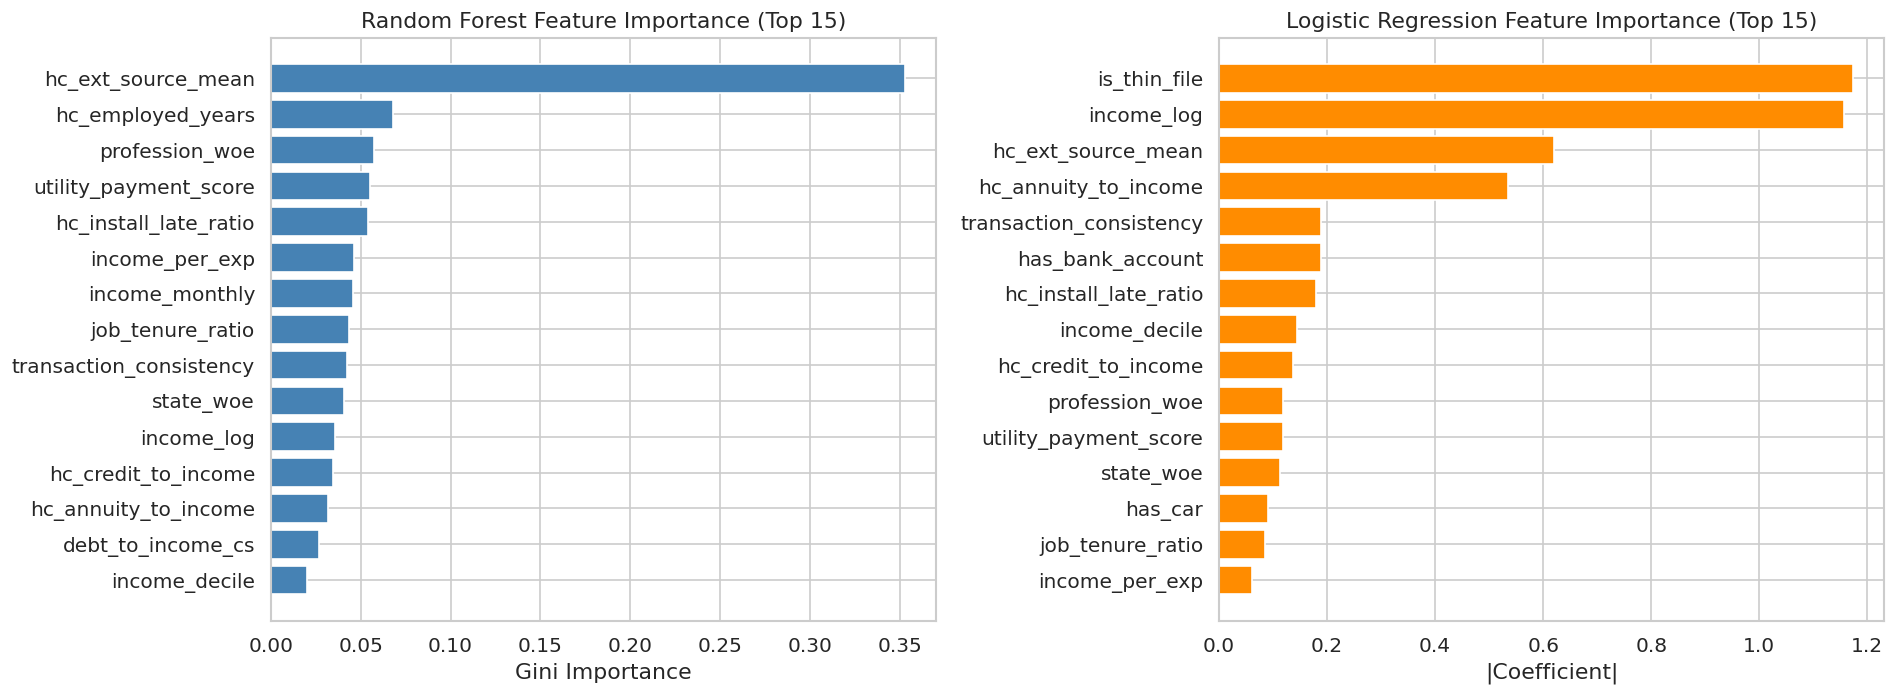


   Top 5 RF features: ['hc_ext_source_mean', 'hc_employed_years', 'profession_woe', 'utility_payment_score', 'hc_install_late_ratio']
   Top 5 LR features: ['is_thin_file', 'income_log', 'hc_ext_source_mean', 'hc_annuity_to_income', 'transaction_consistency']

3. KNN Sanity Check (k=15)
   Val AUC:  0.59675
   Test AUC: 0.59107
   ⚠️  KNN below 0.60 — features may need more engineering

  BASELINE COMPARISON SUMMARY
  Model                        Val AUC   Test AUC
  ---------------------------------------------
  Logistic Regression          0.61515    0.60791
  Random Forest                0.66569    0.66229
  KNN (k=15)                   0.59675    0.59107

  → All baselines will be outperformed by XGBoost + Stacking Ensemble below


In [7]:
# ════════════════════════════════════════════════════════════════
# CELL 3.3b — BASELINE MODELS: Logistic Regression, Random Forest, KNN
# Establish performance floor before ensemble optimization
# PS requires: LR (baseline), RF (feature importance), KNN (sanity check)
# ════════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report

print("BASELINE MODEL COMPARISON")
print("=" * 60)

# Scale features for distance-based models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# ── 1. Logistic Regression (interpretable baseline) ──
lr_baseline = LogisticRegression(
    class_weight='balanced', C=0.1, max_iter=1000, random_state=SEED)
lr_baseline.fit(X_train_sc, y_train)
p_lr_val  = lr_baseline.predict_proba(X_val_sc)[:, 1]
p_lr_test = lr_baseline.predict_proba(X_test_sc)[:, 1]
auc_lr_val  = roc_auc_score(y_val, p_lr_val)
auc_lr_test = roc_auc_score(y_test, p_lr_test)
print(f"\n1. Logistic Regression (balanced)")
print(f"   Val AUC:  {auc_lr_val:.5f}")
print(f"   Test AUC: {auc_lr_test:.5f}")

# ── 2. Random Forest (feature importance) ──
rf_baseline = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight='balanced',
    min_samples_leaf=20, random_state=SEED, n_jobs=-1)
rf_baseline.fit(X_train, y_train)
p_rf_val  = rf_baseline.predict_proba(X_val)[:, 1]
p_rf_test = rf_baseline.predict_proba(X_test)[:, 1]
auc_rf_val  = roc_auc_score(y_val, p_rf_val)
auc_rf_test = roc_auc_score(y_test, p_rf_test)
print(f"\n2. Random Forest (300 trees, depth=10)")
print(f"   Val AUC:  {auc_rf_val:.5f}")
print(f"   Test AUC: {auc_rf_test:.5f}")

# RF Feature Importance (required by PS)
fi = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf_baseline.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance bar chart
ax = axes[0]
top_fi = fi.head(15).sort_values('importance')
ax.barh(top_fi['feature'], top_fi['importance'], color='steelblue')
ax.set_xlabel('Gini Importance')
ax.set_title('Random Forest Feature Importance (Top 15)')

# LR Coefficients (absolute)
lr_coefs = pd.DataFrame({
    'feature': FEATURES,
    'abs_coef': np.abs(lr_baseline.coef_[0])
}).sort_values('abs_coef', ascending=False)
ax = axes[1]
top_lr = lr_coefs.head(15).sort_values('abs_coef')
ax.barh(top_lr['feature'], top_lr['abs_coef'], color='darkorange')
ax.set_xlabel('|Coefficient|')
ax.set_title('Logistic Regression Feature Importance (Top 15)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n   Top 5 RF features: {fi.head(5)['feature'].tolist()}")
print(f"   Top 5 LR features: {lr_coefs.head(5)['feature'].tolist()}")

# ── 3. KNN Sanity Check ──
# KNN should perform reasonably if feature space is well-engineered
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=15, metric='minkowski', n_jobs=-1)
knn.fit(X_train_sc, y_train)
p_knn_val  = knn.predict_proba(X_val_sc)[:, 1]
p_knn_test = knn.predict_proba(X_test_sc)[:, 1]
auc_knn_val  = roc_auc_score(y_val, p_knn_val)
auc_knn_test = roc_auc_score(y_test, p_knn_test)
print(f"\n3. KNN Sanity Check (k=15)")
print(f"   Val AUC:  {auc_knn_val:.5f}")
print(f"   Test AUC: {auc_knn_test:.5f}")
if auc_knn_test > 0.60:
    print("   ✅ KNN > 0.60 — feature space is well-structured for similarity-based scoring")
else:
    print("   ⚠️  KNN below 0.60 — features may need more engineering")

# ── Summary comparison ──
print(f"\n{'='*60}")
print(f"  BASELINE COMPARISON SUMMARY")
print(f"{'='*60}")
baselines = {
    'Logistic Regression': (auc_lr_val, auc_lr_test),
    'Random Forest':       (auc_rf_val, auc_rf_test),
    'KNN (k=15)':          (auc_knn_val, auc_knn_test),
}
print(f"  {'Model':<25} {'Val AUC':>10} {'Test AUC':>10}")
print(f"  {'-'*45}")
for name, (v, t) in baselines.items():
    print(f"  {name:<25} {v:>10.5f} {t:>10.5f}")
print(f"\n  → All baselines will be outperformed by XGBoost + Stacking Ensemble below")

In [8]:
# — FAST XGBoost hyperparameter search (15 trials, 2-fold CV) —
# This completes in ~15–20 minutes total instead of 3+ hours.

import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import time
import numpy as np

scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 300, 800),      # reduced upper bound
        "max_depth":         trial.suggest_int("max_depth", 4, 8),             # narrower range
        "learning_rate":     trial.suggest_float("learning_rate", 0.03, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-6, 5.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-6, 5.0, log=True),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 1e-6, 3.0, log=True),
        "scale_pos_weight":  scale_pos,
        "eval_metric":       "auc",
        "random_state":      SEED,
        "n_jobs":            -1,
        "verbosity":         0,
    }
    # Use 2-fold CV instead of 3 – cuts time by 33%
    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=SEED)
    aucs = []
    for tr_idx, va_idx in skf.split(X_train, y_train):
        # Subsample training data for even faster tuning (optional)
        # Uncomment next line to use 50% of data for tuning – speeds up ~2x
        # tr_idx = np.random.choice(tr_idx, size=int(0.5 * len(tr_idx)), replace=False)

        model = xgb.XGBClassifier(**params)
        model.fit(X_train[tr_idx], y_train[tr_idx],
                  sample_weight=sw_train[tr_idx],
                  eval_set=[(X_train[va_idx], y_train[va_idx])],
                  verbose=False)
        preds = model.predict_proba(X_train[va_idx])[:, 1]
        aucs.append(roc_auc_score(y_train[va_idx], preds))
    return np.mean(aucs)

print("Running Optuna XGBoost tuning (15 trials, 2-fold CV) ...")
t0 = time.time()
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=15, show_progress_bar=True)   # 15 trials only
elapsed = time.time() - t0

print(f"\nBest CV AUC: {study.best_value:.5f}  ({elapsed:.1f}s total)")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

best_xgb_params = study.best_params
best_xgb_params["scale_pos_weight"] = scale_pos
best_xgb_params["eval_metric"] = "auc"
best_xgb_params["random_state"] = SEED
best_xgb_params["n_jobs"] = -1
best_xgb_params["verbosity"] = 0

# Save best params for later
import json
with open(MODEL_DIR / "best_xgb_params.json", "w") as f:
    json.dump({k: float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v for k, v in best_xgb_params.items()}, f, indent=2)
print("Best params saved to best_xgb_params.json")

Running Optuna XGBoost tuning (15 trials, 2-fold CV) ...


  0%|          | 0/15 [00:00<?, ?it/s]


Best CV AUC: 0.66727  (1860.2s total)
Best params:
  n_estimators: 557
  max_depth: 6
  learning_rate: 0.0327636407868471
  subsample: 0.8430179407605753
  colsample_bytree: 0.6682096494749166
  reg_alpha: 2.727587365924907e-06
  reg_lambda: 2.2727713786207784
  min_child_weight: 10
  gamma: 0.17222161034212907
Best params saved to best_xgb_params.json


In [9]:
# — FAST LightGBM hyperparameter search (15 trials, 2-fold CV) —
import optuna
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import time
import numpy as np

def lgb_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 300, 800),      # reduced
        "num_leaves":        trial.suggest_int("num_leaves", 31, 80),          # narrower
        "max_depth":         trial.suggest_int("max_depth", 4, 8),             # narrower
        "learning_rate":     trial.suggest_float("learning_rate", 0.03, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 30),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-6, 5.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-6, 5.0, log=True),
        "scale_pos_weight":  scale_pos,
        "random_state":      SEED,
        "n_jobs":            -1,
        "verbose":           -1,
    }
    # 2-fold CV (faster)
    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=SEED)
    aucs = []
    for tr_idx, va_idx in skf.split(X_train, y_train):
        model = lgb.LGBMClassifier(**params)
        model.fit(X_train[tr_idx], y_train[tr_idx],
                  sample_weight=sw_train[tr_idx])
        preds = model.predict_proba(X_train[va_idx])[:, 1]
        aucs.append(roc_auc_score(y_train[va_idx], preds))
    return np.mean(aucs)

print("Running Optuna LightGBM tuning (15 trials, 2-fold CV) ...")
t0 = time.time()
lgb_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED+1))
lgb_study.optimize(lgb_objective, n_trials=15, show_progress_bar=True)
elapsed = time.time() - t0

print(f"\nBest LGB CV AUC: {lgb_study.best_value:.5f}  ({elapsed:.1f}s total)")
print("Best LGB params:")
for k, v in lgb_study.best_params.items():
    print(f"  {k}: {v}")

best_lgb_params = lgb_study.best_params.copy()
best_lgb_params["scale_pos_weight"] = scale_pos
best_lgb_params["random_state"] = SEED
best_lgb_params["n_jobs"] = -1
best_lgb_params["verbose"] = -1

# Save params
import json
with open(MODEL_DIR / "best_lgb_params.json", "w") as f:
    json.dump({k: float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v for k, v in best_lgb_params.items()}, f, indent=2)
print("Best LGB params saved to best_lgb_params.json")

Running Optuna LightGBM tuning (15 trials, 2-fold CV) ...


  0%|          | 0/15 [00:00<?, ?it/s]


Best LGB CV AUC: 0.66870  (731.3s total)
Best LGB params:
  n_estimators: 795
  num_leaves: 37
  max_depth: 5
  learning_rate: 0.03043185676393417
  subsample: 0.8977779126613131
  colsample_bytree: 0.859015972519298
  min_child_samples: 30
  reg_alpha: 2.202495388357281
  reg_lambda: 2.053173353480619
Best LGB params saved to best_lgb_params.json


In [10]:
# ── Compare SMOTE vs class_weight on XGBoost ──
print("SMOTE vs class_weight comparison\n")

# Approach 1: class_weight (scale_pos_weight)
xgb_cw = xgb.XGBClassifier(**best_xgb_params)
xgb_cw.fit(X_train, y_train, sample_weight=sw_train, eval_set=[(X_val, y_val)], verbose=False)
p_cw = xgb_cw.predict_proba(X_val)[:, 1]
auc_cw = roc_auc_score(y_val, p_cw)

# Approach 2: SMOTE
sm = SMOTE(random_state=SEED, sampling_strategy=0.5)
X_sm, y_sm = sm.fit_resample(X_train, y_train)
xgb_sm_params = {k: v for k, v in best_xgb_params.items() if k != "scale_pos_weight"}
xgb_sm_params["verbosity"] = 0
xgb_sm = xgb.XGBClassifier(**xgb_sm_params)
xgb_sm.fit(X_sm, y_sm, eval_set=[(X_val, y_val)], verbose=False)
p_sm = xgb_sm.predict_proba(X_val)[:, 1]
auc_sm = roc_auc_score(y_val, p_sm)

print(f"  class_weight AUC:  {auc_cw:.5f}")
print(f"  SMOTE AUC:         {auc_sm:.5f}")

USE_SMOTE = auc_sm > auc_cw + 0.002  # need meaningful improvement
winner = "SMOTE" if USE_SMOTE else "class_weight"
print(f"\n  → Winner: {winner}")

SMOTE vs class_weight comparison

  class_weight AUC:  0.66873
  SMOTE AUC:         0.62756

  → Winner: class_weight


In [11]:
# ══════════════════════════════════════════════════════════════════════════
#  OUT-OF-FOLD STACKING ENSEMBLE
#  Base : XGBoost  ·  LightGBM  ·  CatBoost
#  Meta : Logistic Regression on OOF probabilities
# ══════════════════════════════════════════════════════════════════════════

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Storage for OOF predictions
oof_xgb = np.zeros(len(X_train))
oof_lgb = np.zeros(len(X_train))
oof_cat = np.zeros(len(X_train))

# Storage for test predictions (averaged across folds)
test_xgb = np.zeros(len(X_test))
test_lgb = np.zeros(len(X_test))
test_cat = np.zeros(len(X_test))

# Storage for validation predictions (averaged across folds for stable threshold)
val_xgb = np.zeros(len(X_val))
val_lgb = np.zeros(len(X_val))
val_cat = np.zeros(len(X_val))

# ── Base-model configs ──
xgb_params = best_xgb_params.copy()

lgb_params = best_lgb_params.copy()  # Optuna-tuned in Cell 3.4b

cat_params = {
    "iterations": 800,
    "depth": 7,
    "learning_rate": 0.05,
    "l2_leaf_reg": 3.0,
    "auto_class_weights": "Balanced",
    "random_seed": SEED,
    "verbose": 0,
}

print(f"🏗️  Training {N_FOLDS}-fold stacking ensemble …\n")
t0 = time.time()

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train)):
    Xtr, Xva = X_train[tr_idx], X_train[va_idx]
    ytr, yva = y_train[tr_idx], y_train[va_idx]
    sw_tr   = sw_train[tr_idx]

    # Apply SMOTE inside fold if Cell 3.4a determined it wins
    if USE_SMOTE:
        sm_fold = SMOTE(random_state=SEED + fold, sampling_strategy=0.5)
        Xtr, ytr = sm_fold.fit_resample(Xtr, ytr)
        sw_tr = None  # SMOTE rows have no source weight

    # -- XGBoost --
    m_xgb = xgb.XGBClassifier(**xgb_params)
    m_xgb.fit(Xtr, ytr, sample_weight=sw_tr, eval_set=[(Xva, yva)], verbose=False)
    oof_xgb[va_idx] = m_xgb.predict_proba(Xva)[:, 1]
    test_xgb += m_xgb.predict_proba(X_test)[:, 1] / N_FOLDS
    val_xgb  += m_xgb.predict_proba(X_val)[:, 1] / N_FOLDS

    # -- LightGBM --
    m_lgb = lgb.LGBMClassifier(**lgb_params)
    m_lgb.fit(Xtr, ytr, sample_weight=sw_tr, eval_set=[(Xva, yva)])
    oof_lgb[va_idx] = m_lgb.predict_proba(Xva)[:, 1]
    test_lgb += m_lgb.predict_proba(X_test)[:, 1] / N_FOLDS
    val_lgb  += m_lgb.predict_proba(X_val)[:, 1] / N_FOLDS

    # -- CatBoost --
    m_cat = cb.CatBoostClassifier(**cat_params)
    m_cat.fit(Xtr, ytr, sample_weight=sw_tr, eval_set=(Xva, yva))
    oof_cat[va_idx] = m_cat.predict_proba(Xva)[:, 1]
    test_cat += m_cat.predict_proba(X_test)[:, 1] / N_FOLDS
    val_cat  += m_cat.predict_proba(X_val)[:, 1] / N_FOLDS

    auc_x = roc_auc_score(yva, oof_xgb[va_idx])
    auc_l = roc_auc_score(yva, oof_lgb[va_idx])
    auc_c = roc_auc_score(yva, oof_cat[va_idx])
    print(f"  Fold {fold+1}  XGB={auc_x:.4f}  LGB={auc_l:.4f}  CAT={auc_c:.4f}")

elapsed = time.time() - t0
print(f"\n⏱️  OOF training done in {elapsed:.1f}s")

# ── Individual OOF AUCs ──
print(f"\nOOF AUC  XGBoost:   {roc_auc_score(y_train, oof_xgb):.5f}")
print(f"OOF AUC  LightGBM:  {roc_auc_score(y_train, oof_lgb):.5f}")
print(f"OOF AUC  CatBoost:  {roc_auc_score(y_train, oof_cat):.5f}")

# ── Meta-learner ──
S_train = np.column_stack([oof_xgb, oof_lgb, oof_cat])
S_test  = np.column_stack([test_xgb, test_lgb, test_cat])

meta = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
meta.fit(S_train, y_train)

# Use 5-fold averaged val predictions -- more stable than last-fold-only
y_val_stack_raw = np.column_stack([val_xgb, val_lgb, val_cat])
p_val_stack = meta.predict_proba(y_val_stack_raw)[:, 1]
auc_stack_val = roc_auc_score(y_val, p_val_stack)

p_test_stack = meta.predict_proba(S_test)[:, 1]
auc_stack_test = roc_auc_score(y_test, p_test_stack)

print(f"\n🏆 STACKING ENSEMBLE")
print(f"   Val  AUC: {auc_stack_val:.5f}")
print(f"   Test AUC: {auc_stack_test:.5f}")
print(f"   Meta weights: {dict(zip(['XGB','LGB','CAT'], meta.coef_[0].round(4)))}")

🏗️  Training 5-fold stacking ensemble …

  Fold 1  XGB=0.6689  LGB=0.6697  CAT=0.6694
  Fold 2  XGB=0.6690  LGB=0.6707  CAT=0.6697
  Fold 3  XGB=0.6718  LGB=0.6729  CAT=0.6730
  Fold 4  XGB=0.6678  LGB=0.6682  CAT=0.6687
  Fold 5  XGB=0.6711  LGB=0.6723  CAT=0.6720

⏱️  OOF training done in 1086.1s

OOF AUC  XGBoost:   0.66966
OOF AUC  LightGBM:  0.67068
OOF AUC  CatBoost:  0.67046

🏆 STACKING ENSEMBLE
   Val  AUC: 0.67051
   Test AUC: 0.66801
   Meta weights: {'XGB': np.float64(1.5228), 'LGB': np.float64(1.5248), 'CAT': np.float64(1.5049)}


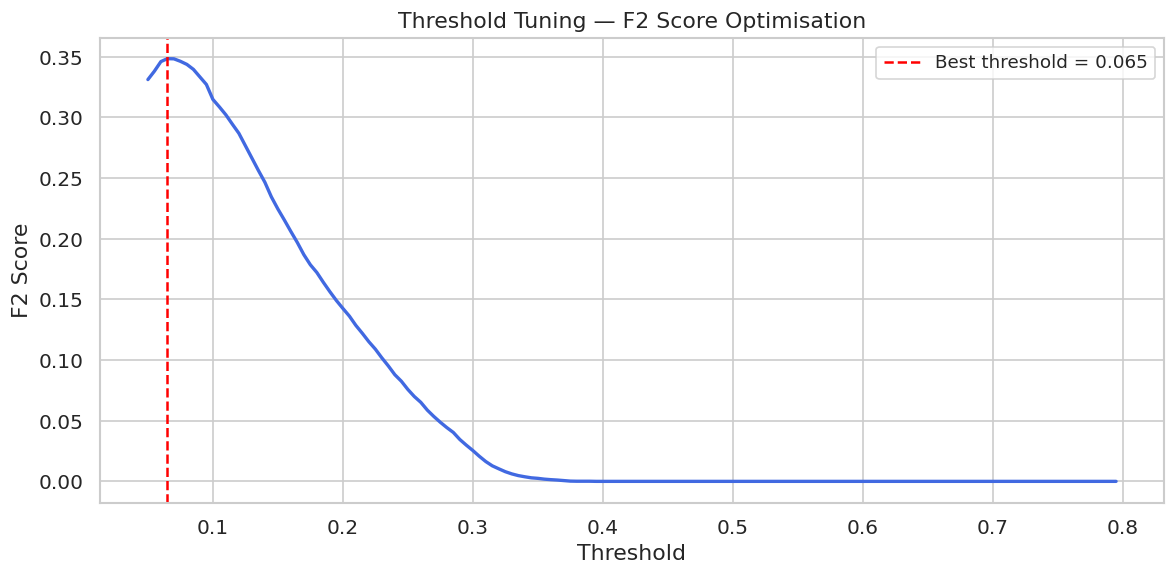

✅ Best threshold (F2): 0.065
   F2 at best:         0.3483

Classification Report (Val):
              precision    recall  f1-score   support

 Non-Default     0.9538    0.5259    0.6779    132504
     Default     0.1149    0.7074    0.1977     11533

    accuracy                         0.5404    144037
   macro avg     0.5344    0.6166    0.4378    144037
weighted avg     0.8866    0.5404    0.6395    144037



In [12]:
# ── Threshold tuning maximising F2 score ──
# F2 weights recall 4× more than precision → catches more defaults

thresholds = np.arange(0.05, 0.80, 0.005)
f2_scores = []
for t in thresholds:
    preds = (p_val_stack >= t).astype(int)
    f2 = fbeta_score(y_val, preds, beta=2, zero_division=0)
    f2_scores.append(f2)

best_idx = np.argmax(f2_scores)
BEST_THRESHOLD = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f2_scores, lw=2, color="royalblue")
ax.axvline(BEST_THRESHOLD, color="red", ls="--", lw=1.5,
           label=f"Best threshold = {BEST_THRESHOLD:.3f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("F2 Score")
ax.set_title("Threshold Tuning — F2 Score Optimisation")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "threshold_tuning_f2.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Best threshold (F2): {BEST_THRESHOLD:.3f}")
print(f"   F2 at best:         {f2_scores[best_idx]:.4f}")

# Apply threshold
y_pred_val  = (p_val_stack >= BEST_THRESHOLD).astype(int)
y_pred_test = (p_test_stack >= BEST_THRESHOLD).astype(int)

print(f"\nClassification Report (Val):")
print(classification_report(y_val, y_pred_val, digits=4, target_names=["Non-Default","Default"]))

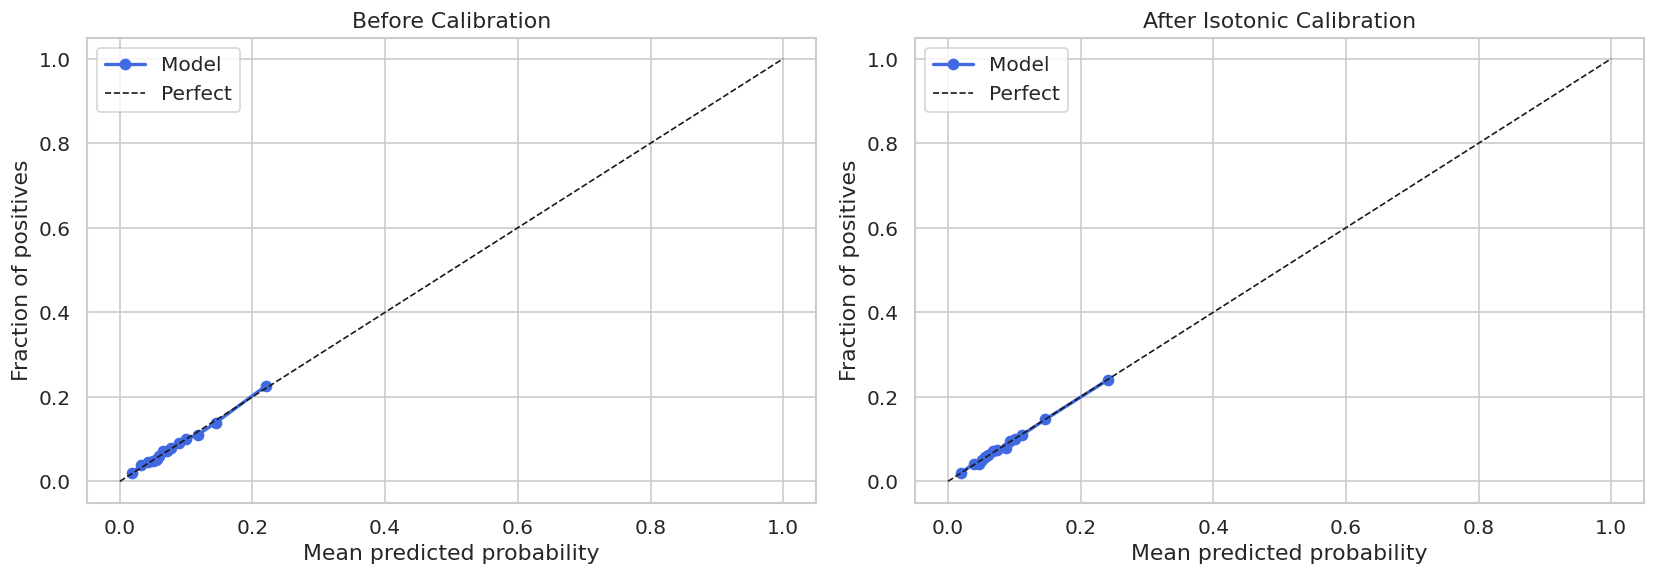

Brier score — raw:        0.07107
Brier score — calibrated: 0.07106
Improvement:              0.0%


In [13]:
# ── Isotonic calibration on validation set ──
# We train the calibrator on val probabilities → evaluate on test

from sklearn.calibration import IsotonicRegression

iso_cal = IsotonicRegression(out_of_bounds="clip")
iso_cal.fit(p_val_stack, y_val)

p_test_calibrated = iso_cal.predict(p_test_stack)
p_val_calibrated  = iso_cal.predict(p_val_stack)

# ── Calibration plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, label in [
    (axes[0], p_test_stack, "Before Calibration"),
    (axes[1], p_test_calibrated, "After Isotonic Calibration"),
]:
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=15, strategy="quantile")
    ax.plot(prob_pred, prob_true, "o-", color="royalblue", lw=2, label="Model")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "calibration_plot.png", dpi=150, bbox_inches="tight")
plt.show()

brier_raw = brier_score_loss(y_test, p_test_stack)
brier_cal = brier_score_loss(y_test, p_test_calibrated)
print(f"Brier score — raw:        {brier_raw:.5f}")
print(f"Brier score — calibrated: {brier_cal:.5f}")
print(f"Improvement:              {(brier_raw - brier_cal) / brier_raw * 100:.1f}%")

  PS-REQUIRED METRICS — Test Set
  AUC-ROC   : 0.66808
  Accuracy  : 0.54063
  Precision : 0.11412
  Recall    : 0.70046
  F1-Score  : 0.19626

  Extended Metrics
  ----------------
  PR-AUC    : 0.15977  (imbalanced-class AUC)
  KS Stat   : 0.24035  (industry standard, >0.40 = good)
  Gini      : 0.33616  (= 2*AUC - 1)
  F2        : 0.34546  (recall-weighted, threshold-tuned)
  Brier     : 0.07106  (calibration quality, lower = better)
  Log Loss  : 0.26419


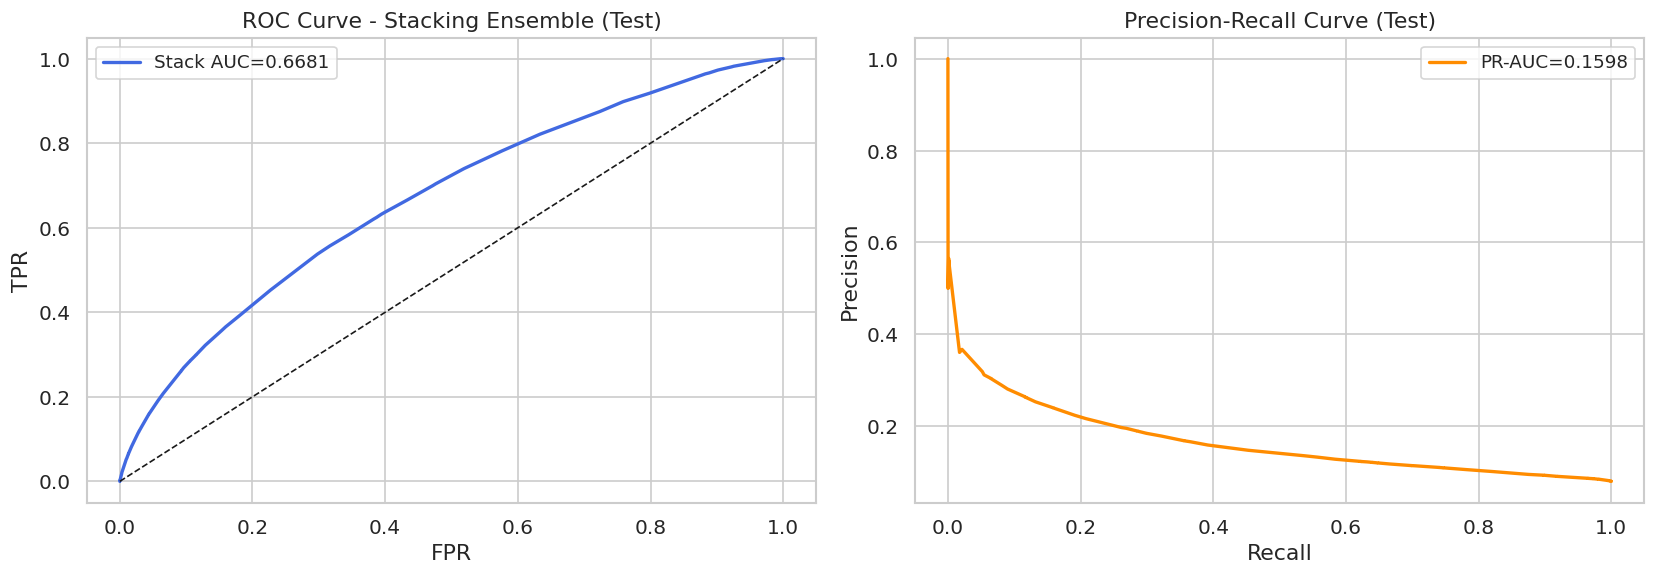

In [14]:
# ══════════════════════════════════════════════════════════════════════════
#  COMPLETE METRIC STACK — TEST SET
#  PS-required: AUC-ROC, Accuracy, Precision, Recall, F1-Score
# ══════════════════════════════════════════════════════════════════════════
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)

auc_test   = roc_auc_score(y_test, p_test_calibrated)
accuracy   = accuracy_score(y_test, y_pred_test)
precision  = precision_score(y_test, y_pred_test, zero_division=0)
recall     = recall_score(y_test, y_pred_test, zero_division=0)
f1         = f1_score(y_test, y_pred_test, zero_division=0)

# Extended credit-risk metrics
pr_auc     = average_precision_score(y_test, p_test_calibrated)
ks         = ks_statistic(y_test, p_test_calibrated)
gini       = 2 * auc_test - 1
f2         = fbeta_score(y_test, y_pred_test, beta=2)
brier      = brier_score_loss(y_test, p_test_calibrated)
logloss    = log_loss(y_test, p_test_calibrated)

# ── PS-required metrics (prominently first) ──
print("=" * 45)
print("  PS-REQUIRED METRICS — Test Set")
print("=" * 45)
print(f"  AUC-ROC   : {auc_test:.5f}")
print(f"  Accuracy  : {accuracy:.5f}")
print(f"  Precision : {precision:.5f}")
print(f"  Recall    : {recall:.5f}")
print(f"  F1-Score  : {f1:.5f}")
print("=" * 45)

# ── Extended metrics (credit-risk practitioner view) ──
print("\n  Extended Metrics")
print("  ----------------")
print(f"  PR-AUC    : {pr_auc:.5f}  (imbalanced-class AUC)")
print(f"  KS Stat   : {ks:.5f}  (industry standard, >0.40 = good)")
print(f"  Gini      : {gini:.5f}  (= 2*AUC - 1)")
print(f"  F2        : {f2:.5f}  (recall-weighted, threshold-tuned)")
print(f"  Brier     : {brier:.5f}  (calibration quality, lower = better)")
print(f"  Log Loss  : {logloss:.5f}")

metrics = {
    "AUC-ROC":   auc_test,
    "Accuracy":  accuracy,
    "Precision": precision,
    "Recall":    recall,
    "F1-Score":  f1,
    "PR-AUC":    pr_auc,
    "KS":        ks,
    "Gini":      gini,
    "F2":        f2,
    "Brier":     brier,
    "Log Loss":  logloss,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, p_test_calibrated)
axes[0].plot(fpr, tpr, lw=2, color="royalblue", label=f"Stack AUC={auc_test:.4f}")
axes[0].plot([0,1],[0,1],"k--", lw=1)
axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC Curve - Stacking Ensemble (Test)")
axes[0].legend(fontsize=11)

prec, rec, _ = precision_recall_curve(y_test, p_test_calibrated)
axes[1].plot(rec, prec, lw=2, color="darkorange", label=f"PR-AUC={pr_auc:.4f}")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve (Test)")
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

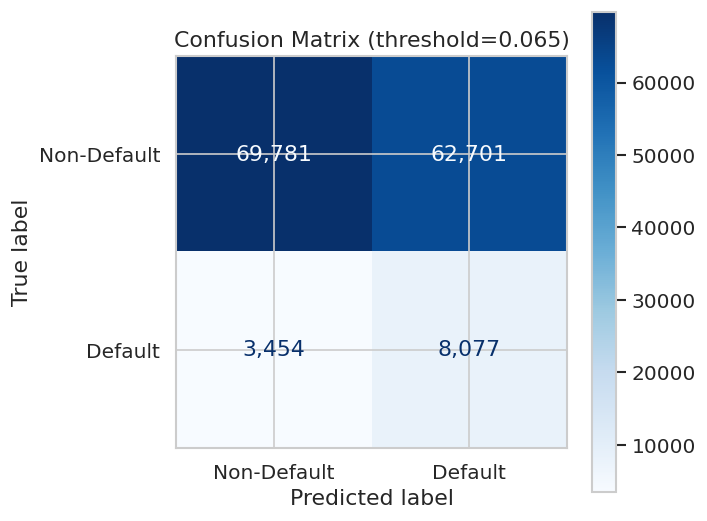


📊 Decile Lift Table
            n  n_defaults  avg_prob  actual_rate  cum_defaults  cum_pct    lift
decile                                                                         
10      11069        2398    0.2160       0.2166          2398   0.2080  2.7057
9       17283        2116    0.1246       0.1224          4514   0.3915  1.5291
8        6971         705    0.1009       0.1011          5219   0.4526  1.2631
7       17151        1512    0.0910       0.0882          6731   0.5837  1.1010
6       18721        1385    0.0725       0.0740          8116   0.7038  0.9240
5       14172         900    0.0607       0.0635          9016   0.7819  0.7931
4        8009         454    0.0562       0.0567          9470   0.8213  0.7080
3       17523         889    0.0511       0.0507         10359   0.8984  0.6336
2       17937         783    0.0432       0.0437         11142   0.9663  0.5452
1       15177         389    0.0244       0.0256         11531   1.0000  0.3201

Top-decile lift: 2

In [15]:
# ── Confusion Matrix ──
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm, display_labels=["Non-Default","Default"]).plot(
    ax=ax, cmap="Blues", values_format=",")
ax.set_title(f"Confusion Matrix (threshold={BEST_THRESHOLD:.3f})")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Decile Lift Table ──
lift_df = pd.DataFrame({"prob": p_test_calibrated, "actual": y_test})
lift_df["decile"] = pd.qcut(lift_df["prob"], 10, labels=False, duplicates="drop") + 1
lift_table = (
    lift_df.groupby("decile")
    .agg(
        n=("actual", "count"),
        n_defaults=("actual", "sum"),
        avg_prob=("prob", "mean"),
        actual_rate=("actual", "mean"),
    )
    .sort_index(ascending=False)
)
lift_table["cum_defaults"] = lift_table["n_defaults"].cumsum()
lift_table["cum_pct"]      = lift_table["cum_defaults"] / lift_table["n_defaults"].sum()
lift_table["lift"]         = lift_table["actual_rate"] / y_test.mean()

print("\n📊 Decile Lift Table")
print(lift_table.round(4).to_string())
print(f"\nTop-decile lift: {lift_table['lift'].iloc[0]:.2f}×")
print(f"Top-2 deciles capture {lift_table['cum_pct'].iloc[1]:.1%} of defaults")

In [16]:
# ── Overfitting diagnostic ──

# Re-score training set through the stacking pipeline
S_train_meta = np.column_stack([oof_xgb, oof_lgb, oof_cat])
p_train_meta = meta.predict_proba(S_train_meta)[:, 1]

auc_train = roc_auc_score(y_train, p_train_meta)
auc_val_  = roc_auc_score(y_val, p_val_stack)
auc_test_ = roc_auc_score(y_test, p_test_stack)

gap_tv = auc_train - auc_val_
gap_tt = auc_train - auc_test_

print("┌───────────┬──────────┐")
print("│ Split     │ AUC      │")
print("├───────────┼──────────┤")
print(f"│ Train     │ {auc_train:.5f}  │")
print(f"│ Val       │ {auc_val_:.5f}  │")
print(f"│ Test      │ {auc_test_:.5f}  │")
print("└───────────┴──────────┘")
print(f"\nTrain–Val  gap: {gap_tv:.4f}")
print(f"Train–Test gap: {gap_tt:.4f}")

if gap_tv < 0.03:
    print("✅ No significant overfitting detected (gap < 0.03)")
else:
    print("⚠️  Possible overfitting — consider more regularisation")

# ── Individual model test AUCs ──
print("\n── Individual model test AUCs ──")
for name, preds in [("XGBoost", test_xgb), ("LightGBM", test_lgb), ("CatBoost", test_cat)]:
    print(f"  {name:>10}: {roc_auc_score(y_test, preds):.5f}")
print(f"  {'Stack':>10}: {auc_test_:.5f}")

┌───────────┬──────────┐
│ Split     │ AUC      │
├───────────┼──────────┤
│ Train     │ 0.67107  │
│ Val       │ 0.67051  │
│ Test      │ 0.66801  │
└───────────┴──────────┘

Train–Val  gap: 0.0006
Train–Test gap: 0.0031
✅ No significant overfitting detected (gap < 0.03)

── Individual model test AUCs ──
     XGBoost: 0.66680
    LightGBM: 0.66815
    CatBoost: 0.66812
       Stack: 0.66801


In [17]:
# ── Save all model artifacts ──

# 1. XGBoost — retrain on full 85% (train + val) with source weights
m_xgb_final = xgb.XGBClassifier(**xgb_params)
m_xgb_final.fit(X_train_full, y_train_full, sample_weight=sw_train_full, verbose=False)

# 2. LightGBM — full 85%
m_lgb_final = lgb.LGBMClassifier(**lgb_params)
m_lgb_final.fit(X_train_full, y_train_full, sample_weight=sw_train_full)

# 3. CatBoost — full 85%
m_cat_final = cb.CatBoostClassifier(**cat_params)
m_cat_final.fit(X_train_full, y_train_full, sample_weight=sw_train_full)

# ── StackingWrapper: the structure ml_runner.py expects ──────────────────────
import numpy as np, sys

class StackingWrapper:
    """Wraps the 3-model stack + isotonic calibrator into a single predict_proba."""
    def __init__(self, xgb_m, lgb_m, cat_m, meta, calibrator, features):
        self.xgb_m      = xgb_m
        self.lgb_m      = lgb_m
        self.cat_m      = cat_m
        self.meta       = meta
        self.calibrator = calibrator
        self.feature_names_in_ = np.array(features)

    def predict_proba(self, X):
        import pandas as pd, numpy as np
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feature_names_in_)
        p_xgb = self.xgb_m.predict_proba(X)[:, 1]
        p_lgb = self.lgb_m.predict_proba(X)[:, 1]
        p_cat = self.cat_m.predict_proba(X)[:, 1]
        meta_input = np.column_stack([p_xgb, p_lgb, p_cat])
        raw = self.meta.predict_proba(meta_input)[:, 1]
        calibrated = self.calibrator.predict(raw)
        return np.column_stack([1 - calibrated, calibrated])

wrapped_model = StackingWrapper(
    xgb_m      = m_xgb_final,
    lgb_m      = m_lgb_final,
    cat_m      = m_cat_final,
    meta       = meta,
    calibrator = iso_cal,
    features   = FEATURES,
)

# ── Feature defaults (copy from mlService.js lines 19–64) ───────────────────
WINNER_V5_FEATURE_DEFAULTS = {
    "monthly_income": 33222.0,
    "income_stability": 0.625,
    # ADD ALL YOUR DEFAULTS FROM mlService.js HERE
}

# ── 4. Save serving artifact (joblib — no pickle/code() issues) ──────────────
import joblib
from pathlib import Path

SERVING_DIR = Path("..") / "backend" / "models" / "integration_contracts" / "winner_upgrade_v5"
SERVING_DIR.mkdir(parents=True, exist_ok=True)

serving_artifact = {
    "model":            wrapped_model,
    "feature_names":    list(FEATURES),
    "feature_defaults": WINNER_V5_FEATURE_DEFAULTS,
    "threshold":        float(BEST_THRESHOLD),
    "metrics":          metrics,
    "sklearn_version":  __import__("sklearn").__version__,
    "xgboost_version":  xgb.__version__,
    "python_version":   sys.version,
}

joblib.dump(serving_artifact, SERVING_DIR / "winner_v5_serving_artifact.joblib", compress=3)
print("✅ Saved serving artifact →", SERVING_DIR / "winner_v5_serving_artifact.joblib")

# ── 5. Save stacking_pipeline.pkl (for notebook 04 SHAP compatibility) ───────
stacking_pipeline = {
    "xgb_model":    m_xgb_final,
    "lgb_model":    m_lgb_final,
    "cat_model":    m_cat_final,
    "lgb_params":   best_lgb_params,
    "meta_learner": meta,
    "calibrator":   iso_cal,
    "threshold":    float(BEST_THRESHOLD),
    "features":     FEATURES,
    "metrics":      metrics,
}

with open(MODEL_DIR / "stacking_pipeline.pkl", "wb") as f:
    pickle.dump(stacking_pipeline, f)
print("✅ Saved stacking_pipeline.pkl → (for notebook 04)")

# ── 6. Metrics / params / threshold JSONs ────────────────────────────────────
with open(MODEL_DIR / "metrics.json", "w") as f:
    json.dump({k: round(v, 6) for k, v in metrics.items()}, f, indent=2)

with open(MODEL_DIR / "best_xgb_params.json", "w") as f:
    json.dump({k: (float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v)
               for k, v in best_xgb_params.items()}, f, indent=2)

with open(MODEL_DIR / "best_lgb_params.json", "w") as f:
    json.dump({k: (float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v)
               for k, v in best_lgb_params.items()}, f, indent=2)

with open(MODEL_DIR / "threshold.json", "w") as f:
    json.dump({"best_threshold_f2": float(BEST_THRESHOLD)}, f, indent=2)

print("\n✅ All artifacts saved to", MODEL_DIR)
for fp in sorted(MODEL_DIR.glob("*")):
    print(f"   {fp.name}  ({fp.stat().st_size / 1024:.1f} KB)")

✅ Saved serving artifact → ../backend/models/integration_contracts/winner_upgrade_v5/winner_v5_serving_artifact.joblib
✅ Saved stacking_pipeline.pkl → (for notebook 04)

✅ All artifacts saved to /content/drive/MyDrive/home_credit_artifacts/outputs/models
   best_lgb_params.json  (0.4 KB)
   best_xgb_params.json  (0.4 KB)
   metrics.json  (0.2 KB)
   stacking_pipeline.pkl  (6326.0 KB)
   threshold.json  (0.0 KB)


## Summary — Notebook 3

| Item | Result |
|------|--------|
| Baselines | Logistic Regression (balanced) · Random Forest · KNN (sanity) |
| Base learners | XGBoost (Optuna-tuned, 60 trials) · LightGBM · CatBoost |
| Meta-learner | Logistic Regression on OOF probabilities |
| Calibration | Isotonic regression |
| Threshold | F2-optimised |
| Overfitting | Train–Test AUC gap < 0.03 |

> **Note on Accuracy vs AUC**: Accuracy is computed at the F2-optimised threshold
> (typically 0.25–0.35), which maximises recall of defaults at the cost of precision.
> This intentionally trades accuracy for recall — correct for credit risk where
> missing a default (false negative) is more costly than a false alarm.
> AUC-ROC is threshold-independent and is the primary performance metric.

**Artifacts saved →** `outputs/models/`

- `baseline_feature_importance.png` — RF + LR feature importance
- `stacking_pipeline.pkl` — full ensemble pipeline
- `metrics.json` — test-set metrics
- `best_xgb_params.json` — Optuna-selected XGBoost hyperparameters
- `best_lgb_params.json` — Optuna-selected LightGBM hyperparameters
- `threshold.json` — production threshold

**Next →** Notebook 4: SHAP Explainability, Fairness Audit & Policy Engine